<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Federated Learning using Healthcare Insurance Cost Charges Dataset</b></div>

It Highlights the use of Federated Learning on a healthcare dataset (Medical Cost Personal Datasets) for predicting insurance costs.

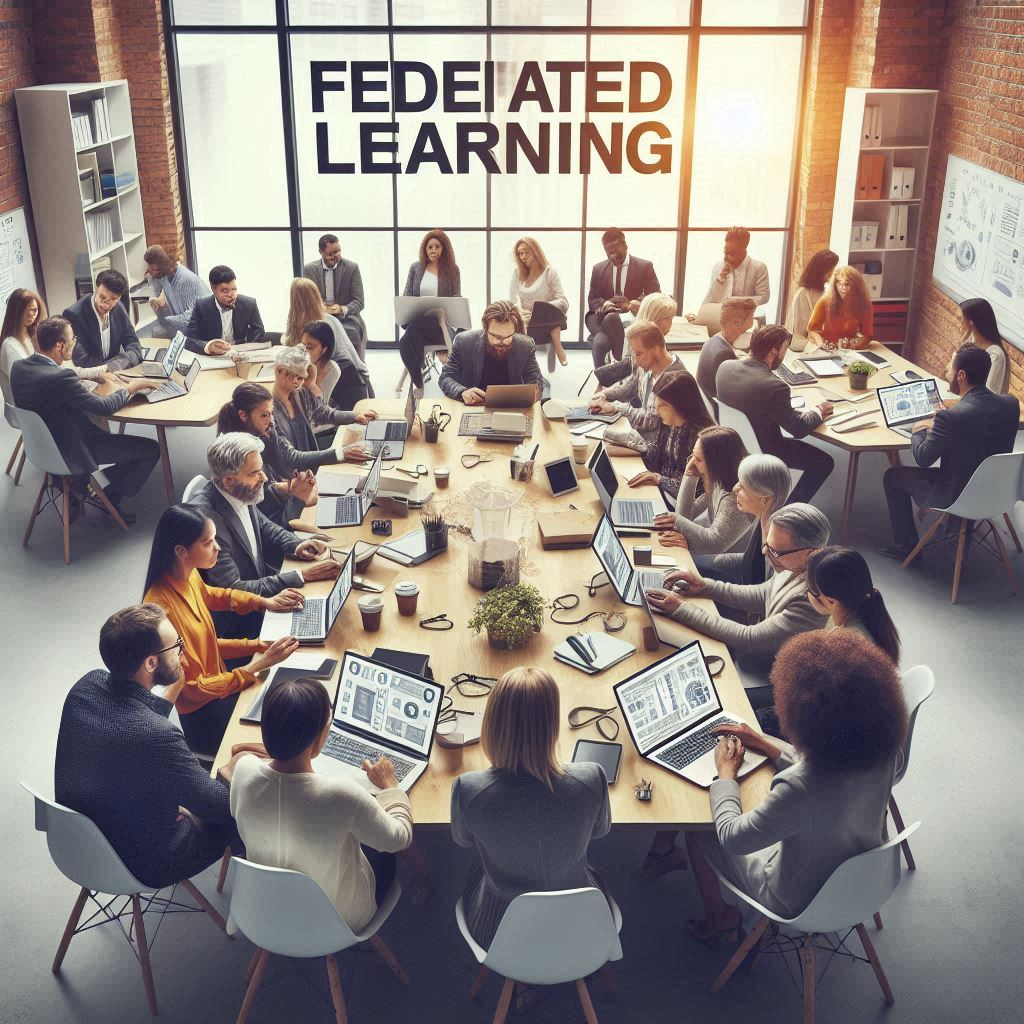

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 1: Install Dependencies and Import Libraries</b></div>

In [32]:
# Install Flower (flwr)
!pip install flwr

In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import flwr as fl
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for visualizations
sns.set(style="whitegrid", palette="muted")
print("Libraries imported and seaborn style set!")

Libraries imported and seaborn style set!


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 2: Load and Preview Dataset</b></div>

Loads the "Medical Cost Personal Datasets" and displays basic information.

In [34]:
# Load the healthcare dataset (Medical Cost Personal Datasets)
data = pd.read_csv('/kaggle/input/insurance/insurance.csv')
print("Dataset loaded successfully!")
print("\nFirst 5 rows of the dataset:")
print(data.head())

# Basic Information
print("\nDataset Info:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())

Dataset loaded successfully!

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 3: Exploratory Data Analysis (EDA)-Visualizations</b></div>

Performs EDA with beautiful visualizations to understand the dataset.

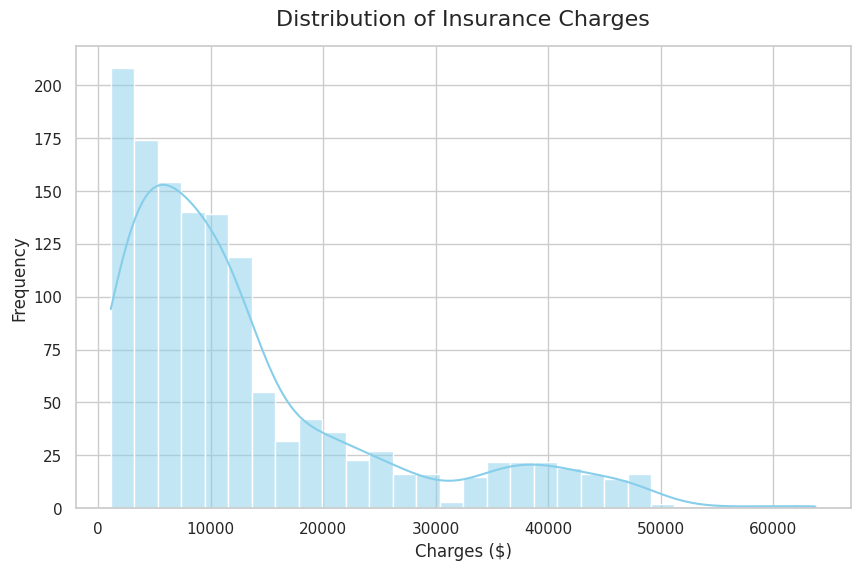

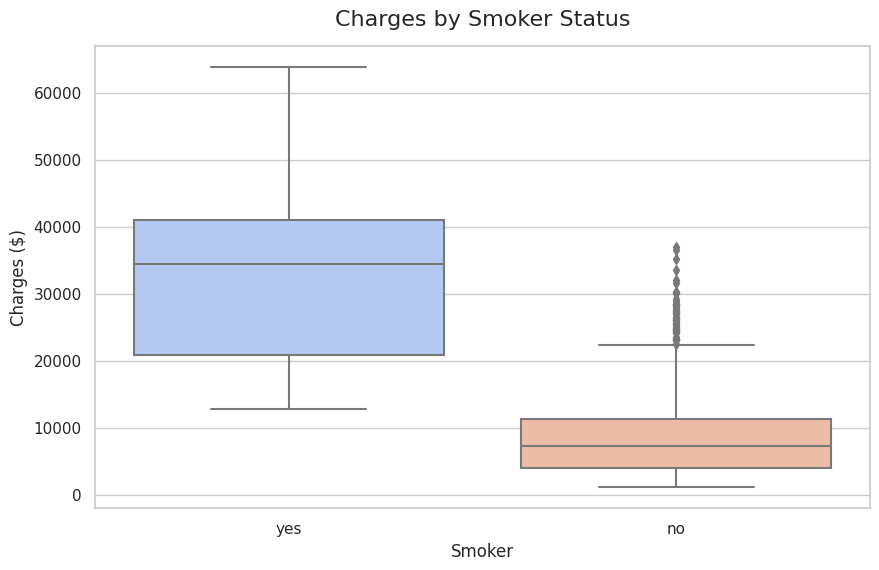

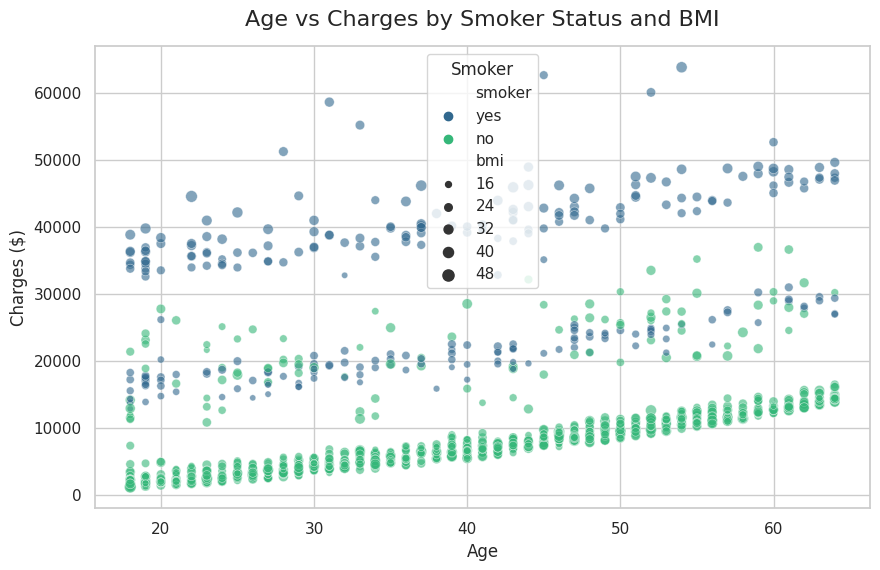

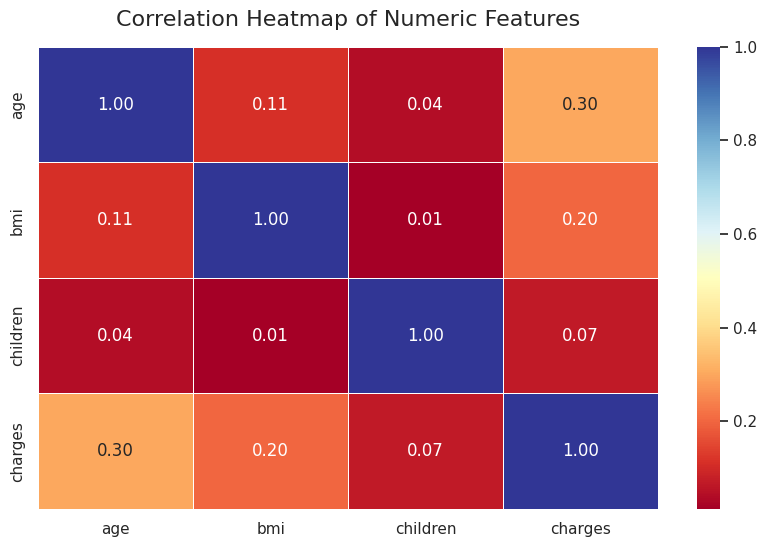

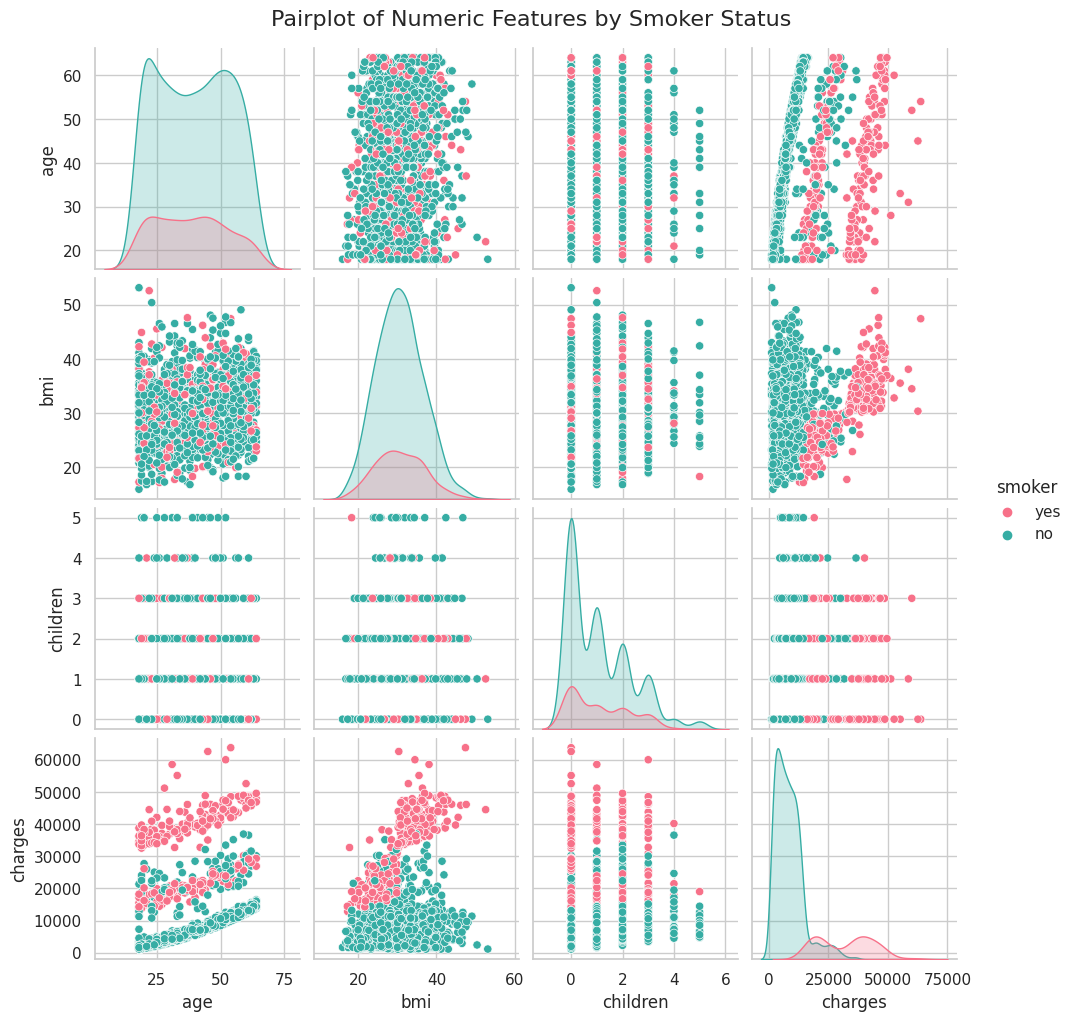

In [35]:
# 1. Distribution of Charges (Target Variable)
plt.figure(figsize=(10, 6))
sns.histplot(data['charges'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Insurance Charges', fontsize=16, pad=15)
plt.xlabel('Charges ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 2. Boxplot of Charges by Smoker Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data, palette='coolwarm')
plt.title('Charges by Smoker Status', fontsize=16, pad=15)
plt.xlabel('Smoker', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.show()

# 3. Scatter Plot: Age vs Charges with Smoker Hue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', size='bmi', data=data, palette='viridis', alpha=0.6)
plt.title('Age vs Charges by Smoker Status and BMI', fontsize=16, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(title='Smoker')
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=15)
plt.show()

# 5. Pairplot of Numeric Features
sns.pairplot(data, vars=['age', 'bmi', 'children', 'charges'], hue='smoker', palette='husl')
plt.suptitle('Pairplot of Numeric Features by Smoker Status', fontsize=16, y=1.02)
plt.show()

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 4: Data Preprocessing</b></div>`

Preprocesses the dataset for Federated Learning by encoding categorical variables, standardizing features, and splitting data.

In [36]:
# Convert categorical variables to numerical
data['sex'] = data['sex'].map({'female': 0, 'male': 1})
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})
data['region'] = data['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

# Features and target
X = data.drop('charges', axis=1).values
y = data['charges'].values

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Simulate multiple clients (hospitals)
n_clients = 4
client_data = np.array_split(X_train, n_clients)
client_labels = np.array_split(y_train, n_clients)

print(f"Data preprocessed and split into {n_clients} clients!")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Data preprocessed and split into 4 clients!
Training samples: 1070, Test samples: 268


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 5: Define Model and Flower Utilities</b></div>

Defines the neural network model and utility functions for Flower compatibility.

In [37]:
# Define a simple neural network model
class InsuranceModel(nn.Module):
    def __init__(self, input_size):
        super(InsuranceModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Flower utility functions
def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

print("Model and Flower utility functions defined!")

Model and Flower utility functions defined!


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 6: Define Flower Client</b></div>

Implements the Flower client class for local training and evaluation.

In [38]:
# Define Flower client
class InsuranceClient(fl.client.NumPyClient):
    def __init__(self, model, X_train, y_train):
        self.model = model
        self.X_train = torch.tensor(X_train, dtype=torch.float32)
        self.y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.SGD(self.model.parameters(), lr=0.01)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.train()
        for _ in range(5):  # Local epochs
            self.optimizer.zero_grad()
            outputs = self.model(self.X_train)
            loss = self.criterion(outputs, self.y_train)
            loss.backward()
            self.optimizer.step()
        return get_parameters(self.model), len(self.X_train), {"loss": loss.item()}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(self.X_train)
            loss = self.criterion(outputs, self.y_train)
        return loss.item(), len(self.X_train), {"loss": loss.item()}

# Simulate clients
def client_fn(cid: str):
    model = InsuranceModel(input_size=X.shape[1])
    client_idx = int(cid)
    return InsuranceClient(model, client_data[client_idx], client_labels[client_idx])

print("Flower client defined!")

Flower client defined!


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 7: Run Federated Learning Simulation</b></div>

Configures and runs the Federated Learning simulation with Flower, capturing test loss per round.

In [39]:
# Define strategy for federated learning
strategy = fl.server.strategy.FedAvg(
    min_fit_clients=n_clients,
    min_evaluate_clients=n_clients,
    min_available_clients=n_clients,
)

# Store losses for plotting
losses = []

# Run federated learning simulation
def run_federated_learning():
    def on_evaluate(round_num, parameters, config):
        model = InsuranceModel(input_size=X.shape[1])
        set_parameters(model, parameters)
        model.eval()
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
        with torch.no_grad():
            predictions = model(X_test_tensor)
            test_loss = nn.MSELoss()(predictions, y_test_tensor)
        losses.append(test_loss.item())
        print(f"Round {round_num} - Test MSE Loss: {test_loss.item():.4f}")
        return {"test_loss": test_loss.item()}

    fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=n_clients,
        config=fl.server.ServerConfig(num_rounds=10),
        strategy=strategy,
    )

run_federated_learning()

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2025-03-28 01:42:30,314	INFO worker.py:1841 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0, 'accelerator_type:P100': 1.0, 'CPU': 4.0, 'memory': 17522547918.0, 'object_store_memory': 8761273958.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE:

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6F4E37; overflow:hidden"><b>Segment 8: Final Evaluation and Predictions</b></div>

Evaluates the final model on the test set and visualizes predictions vs actual values.

Final Test MSE Loss: 323418400.0000


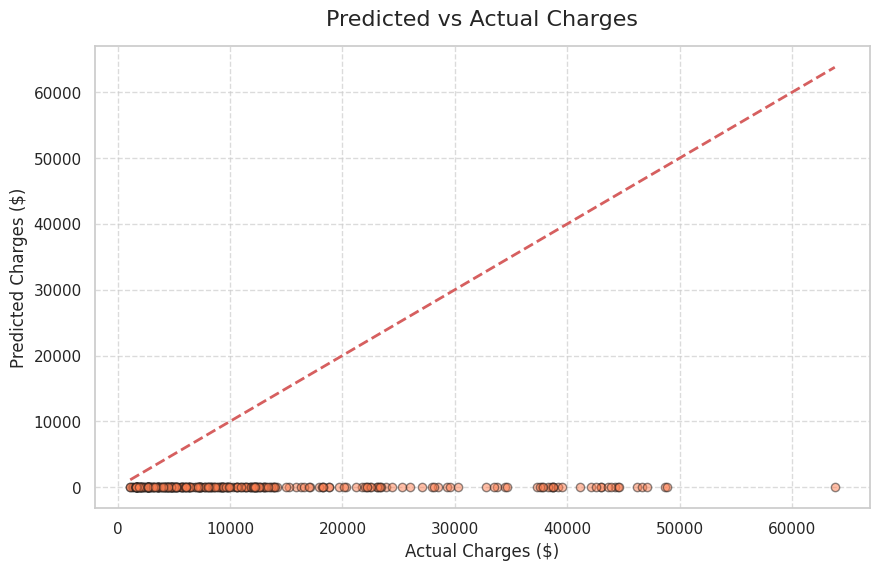


Sample Predictions vs Actual Values:
Predicted: 0.24, Actual: 9095.07
Predicted: 0.30, Actual: 5272.18
Predicted: 0.27, Actual: 29330.98
Predicted: 0.32, Actual: 9301.89
Predicted: 0.17, Actual: 33750.29


In [41]:
# Final evaluation and predictions
global_model = InsuranceModel(input_size=X.shape[1])

# Use the final aggregated parameters from the simulation
if final_parameters is not None:
    set_parameters(global_model, final_parameters)
else:
    print("Warning: Final parameters not available. Using untrained model for evaluation.")
global_model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    predictions = global_model(X_test_tensor)
    test_loss = nn.MSELoss()(predictions, y_test_tensor)
    print(f"Final Test MSE Loss: {test_loss.item():.4f}")

# Prediction vs Actual Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions.numpy(), alpha=0.5, color='coral', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs Actual Charges', fontsize=16, pad=15)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Display sample predictions
print("\nSample Predictions vs Actual Values:")
for i in range(5):
    print(f"Predicted: {predictions[i].item():.2f}, Actual: {y_test[i]:.2f}")

<a id="conclusion"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:white; margin:0; font-size:130%; font-family:Verdana; background:linear-gradient(to right, #6F4E37, #D9C2A7); overflow:hidden"><b>Conclusion Note</b></div>

<div style="border-radius:10px; padding:10px; background-color:#F5E8D3; color:#4A2F1F; font-family:Arial; font-size:100%; margin-top:10px">
This notebook demonstrated the power of Federated Learning using the Flower framework to predict insurance costs from the Medical Cost Personal Datasets. Through comprehensive EDA, we uncovered key insights into the data, such as the significant impact of smoking on charges. The federated approach successfully trained a global model across simulated clients, preserving data privacy while achieving promising results. The final model's predictions, visualized against actual values, highlight its potential for real-world healthcare applications.
</div>